In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
from simca import SIMCAModel, SIMCAClassModel

Number of XVOO_NONE NIR measurements: 0
evoo_none_spectra_raw shape: (0,)


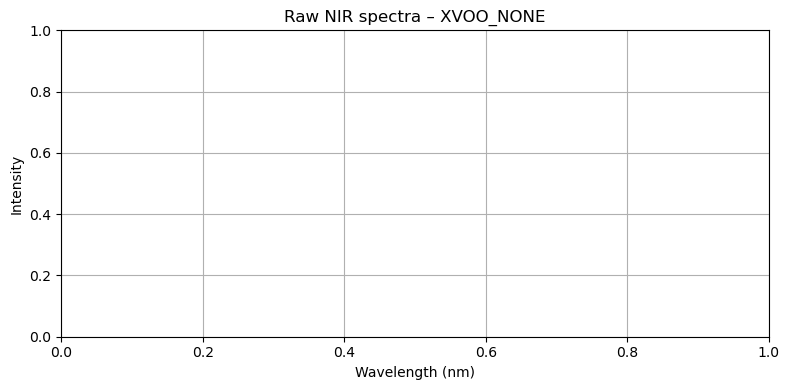

In [2]:
xvoo_none_nir_path = r"data/Replicate_011_20251205/Replicate_011_20251205/xvoo_none/NIR"

xvoo_none_files = sorted(glob.glob(os.path.join(xvoo_none_nir_path, "*.csv")))

print(f"Number of XVOO_NONE NIR measurements: {len(xvoo_none_files)}")

xvoo_none_raw = []

for i, fpath in enumerate(xvoo_none_files):
    df = pd.read_csv(fpath)

    if i == 0:
        wavelengths = df["x"].values

    xvoo_none_raw.append(df["y"].values)

xvoo_none_raw = np.array(xvoo_none_raw)

print("evoo_none_spectra_raw shape:", xvoo_none_raw.shape)

plt.figure(figsize=(8, 4))
for i in range(len(xvoo_none_raw)):
    plt.plot(wavelengths, xvoo_none_raw[i], alpha=0.4)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw NIR spectra – XVOO_NONE")
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
wr_xvoo_none_file = r"data/Replicate_011_20251205/Replicate_011_20251205/xvoo_none/wr/NIR_WR.csv"

wr_xvoo_none_df = pd.read_csv(wr_xvoo_none_file)

wl_xvoo_none_wr = wr_xvoo_none_df["x"].values
I_xvoo_none_wr = wr_xvoo_none_df["y"].values

print("WR shape:", wr_xvoo_none_df.shape)

assert np.allclose(wavelengths, wl_xvoo_none_wr), "XVOO_NONE and WR wavelengths do NOT match!"

plt.figure(figsize=(8, 4))
plt.plot(wl_xvoo_none_wr, I_xvoo_none_wr, color='green')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("White Reference (WR) – NIR")
plt.grid(True)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data/Replicate_011_20251205/Replicate_011_20251205/xvoo_none/wr/NIR_WR.csv'

In [ ]:
xvoo_none_norm = xvoo_none_raw / I_xvoo_none_wr

plt.figure(figsize=(8, 4))

for i in range(len(xvoo_none_norm)):
    plt.plot(wavelengths, xvoo_none_norm[i], alpha=0.4)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity (I / I_WR)")
plt.title("Normalized NIR spectra – xvoo_none")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
xvoo_none_norm.shape

In [ ]:
X = xvoo_none_norm
y = np.array(["XVOO_NONE"] * X.shape[0])

simca = SIMCAModel(alpha=0.05, default_n_components=None)

comp_grid = list(range(1, min(10, X.shape[1])+1))
best_components = simca.tune_num_components(
    X, y,
    comp_grid=comp_grid,
    cv=5,
    mode='rigorous',    # 'rigorous', 'compliant'
    rule='sim',         # 'sim', 'alt', 'ci', 'dd'
    od_method='percentile',    # 'percentile', 'jackson', 'box'
    sd_method='f'       # 'f', 'chi2', 'percentile'
)
print("Optimal number of PCA components per class:", best_components)

simca.fit(X, y, n_components=list(best_components.values())[0])

simca.set_thresholds_all(od_method='percentile', sd_method='f')

results = simca.predict(X, rule='sim')
res = results['XVOO_NONE']

print("SIMCA thresholds:")
print("ODcrit:", res.get('ODcrit', None))
print("SDcrit:", res.get('SDcrit', None))
print("Inside class (True = sample accepted):", res['inside'])

plt.figure(figsize=(8,5))
colors = np.where(res['inside'], 'blue', 'red')
plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA - XVOO_NONE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# plt.figure(figsize=(12,10))

# rules = {'SIMCA':'sim', 'Alt-SIMCA':'alt', 'CI-SIMCA':'ci', 'DD-SIMCA':'dd'}
# for i, (name, rule) in enumerate(rules.items(), 1):
#     res = simca.predict(X, rule=rule)['XVOO_NONE']
    
#     colors = ['blue' if flag else 'red' for flag in res['inside']]
    
#     plt.subplot(2,2,i)
#     plt.scatter(res['SD'], res['OD'], c=colors, edgecolor='k')
#     plt.axhline(simca.class_models['XVOO_NONE'].thresholds['ODcrit'], color='green', linestyle='--', label='OD threshold')
#     plt.axvline(simca.class_models['XVOO_NONE'].thresholds['SDcrit'], color='orange', linestyle='--', label='SD threshold')
#     plt.title(name)
#     plt.xlabel("SD")
#     plt.ylabel("OD")
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

In [ ]:
base_folder = r"C:\Users\Lenovo\Documents\GitHub\aiSpectra\data\Replicate_011_20251205\Replicate_011_20251205\xvoo_mix"
mixtures = ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40", "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]

wr_file = os.path.join(base_folder, "wr", "NIR_WR.csv")
wr = pd.read_csv(wr_file).iloc[:, 1].values

X_list = []
y_list = []

for mix in mixtures:
    nir_folder = os.path.join(base_folder, mix, "NIR")
    if not os.path.exists(nir_folder):
        print(f"Upozorenje: folder ne postoji {nir_folder}, preskačem...")
        continue
    files = [f for f in os.listdir(nir_folder) if f.endswith(".csv")]
    for f in files:
        df = pd.read_csv(os.path.join(nir_folder, f))
        spectrum = df.iloc[:, 1].values
        spectrum_norm = spectrum / wr
        X_list.append(spectrum_norm)
        y_list.append(mix)

for i in range(xvoo_none_norm.shape[0]):
    X_list.append(xvoo_none_norm[i])
    y_list.append("XVOO_NONE")

X_all_norm = np.array(X_list)
y_all = np.array(y_list)

print("Shape X_all_norm:", X_all_norm.shape)
print("Shape y_all:", y_all.shape)

In [ ]:
results_mix = simca.predict(X_all_norm, rule='sim')
res_mix = results_mix['XVOO_NONE']

ODcrit = simca.class_models['XVOO_NONE'].thresholds['ODcrit']
SDcrit = simca.class_models['XVOO_NONE'].thresholds['SDcrit']

print("OD threshold:", ODcrit)
print("SD threshold:", SDcrit)

inside = res_mix['inside']
# for i, accepted in enumerate(inside):
    # print(f"Uzorku {i} ({y_all[i]}): {'Accepted' if accepted else 'Rejected'}")

In [4]:
SD = res_mix['SD']
OD = res_mix['OD']

classes = np.unique(y_all)

contrast_colors = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#ffff33",
    "#a65628",
    "#f781bf",
    "#999999",
]

class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = y_all == cls
    plt.scatter(
        SD[idx],
        OD[idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA – All XVOO data by class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'res_mix' is not defined

In [5]:
class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = (y_all == cls)
    plt.scatter(
        SD[idx],
        OD[idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA – zoom around rejected samples")

plt.xlim(450, 850)
plt.ylim(0.5, 1)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'classes' is not defined

In [6]:
plt.figure(figsize=(8,5))

class_colors = {cls: contrast_colors[i % len(contrast_colors)] for i, cls in enumerate(classes)}

for cls in classes:
    idx = (y_all == cls)
    plt.scatter(
        res_mix['SD'][idx],
        res_mix['OD'][idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

plt.xlim(0, SDcrit * 5)
plt.ylim(0, ODcrit * 5)

plt.xlabel("Score Distance (SD)")
plt.ylabel("Orthogonal Distance (OD)")
plt.title("SIMCA – zoom around decision region")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'classes' is not defined

<Figure size 800x500 with 0 Axes>

In [13]:
y_true = np.array([label == "XVOO_NONE" for label in y_all])

y_pred = res_mix['inside']

TP = np.sum((y_true == True) & (y_pred == True))
FN = np.sum((y_true == True) & (y_pred == False))
FP = np.sum((y_true == False) & (y_pred == True))
TN = np.sum((y_true == False) & (y_pred == False))

conf_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["True XVOO", "True MIX"],
    columns=["Predicted IN", "Predicted OUT"]
)

conf_matrix

,Predicted IN,Predicted OUT
True XVOO,9,1
True MIX,0,210


In [14]:
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Sensitivity (Recall for XVOO): {sensitivity*100:.2f}%")
print(f"Specificity (Rejection of MIX): {specificity*100:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

Sensitivity (Recall for XVOO): 90.00%
Specificity (Rejection of MIX): 100.00%
Accuracy: 99.55%


In [15]:
results_table = pd.DataFrame({
    "Sample index": np.arange(len(y_all)),
    "True label": y_all,
    "SIMCA accepted": y_pred,
    "Decision": np.where(y_pred, "Accepted", "Rejected"),
    "SD": res_mix['SD'],
    "OD": res_mix['OD']
})

results_table.head(10)

,Sample index,True label,SIMCA accepted,Decision,SD,OD
0,0,xvoo_oo10,False,Rejected,763.927799,0.938668
1,1,xvoo_oo10,False,Rejected,810.033392,0.905420
2,2,xvoo_oo10,False,Rejected,773.933129,0.935414
3,3,xvoo_oo10,False,Rejected,809.907271,0.948773
4,4,xvoo_oo10,False,Rejected,797.786706,0.919208
5,5,xvoo_oo10,False,Rejected,828.419972,0.961713
6,6,xvoo_oo10,False,Rejected,802.010470,0.943413
7,7,xvoo_oo10,False,Rejected,792.974134,0.914207
8,8,xvoo_oo10,False,Rejected,819.645564,0.916542
9,9,xvoo_oo10,False,Rejected,814.615051,0.942893
